# Maven Roasters Coffee Shop — Mini Project

You've explored various charts and practised the core principles of good data visualisation. Now it's time to go solo and apply data visualisation to answer some real-world data questions.

This project uses a real-world-style dataset from **Maven Roasters**, a fictitious NYC coffee shop with three locations. Your job is to explore the data and answer 7 business questions using charts.

---

### How this notebook works

Each task follows the same structure:

1. **Business question**, the columns you'll need
2. **Your basic chart** — a blank cell for your first attempt. You need to decide which chart to use.
3. **Things to look out for + optional extras** — hints to improve your chart
4. **Your improved chart** — a blank cell to apply the improvements

Try each step yourself before peeking at the answers!

---

### Dataset
**Coffee Shop Sales — Maven Roasters**  
Downloaded from Kaggle: https://www.kaggle.com/datasets/ahmedabbas757/coffee-sales

~149,000 transactions from Jan–Jun 2023 across three NYC locations.

| Column | Description |
|--------|-------------|
| `transaction_id` | Unique ID per transaction |
| `transaction_date` | Date of purchase (DD/MM/YYYY) |
| `transaction_time` | Time of purchase (HH:MM:SS) |
| `transaction_qty` | Number of items purchased |
| `store_location` | Store name: Astoria, Hell's Kitchen, or Lower Manhattan |
| `unit_price` | Price per item ($) |
| `product_category` | High-level category, e.g. Coffee, Tea, Bakery |
| `product_type` | More specific type, e.g. Brewed Chai Tea, Scone |
| `product_detail` | Full product name |

> There is no `revenue` column — the Setup cell creates it for you: `revenue = transaction_qty × unit_price`

---
## Setup — Run This First

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('coffee_shop_sales.csv')

# Note: dates in this file are DD/MM/YYYY format, so we use dayfirst=True
df['transaction_date'] = pd.to_datetime(df['transaction_date'], dayfirst=True)
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time
df['month_name'] = df['transaction_date'].dt.strftime('%b')
df['day_name']   = df['transaction_date'].dt.strftime('%a')
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
df['revenue']    = df['transaction_qty'] * df['unit_price']

print(f"✅ Loaded {len(df):,} transactions from {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")
print(f"   Stores:     {list(df['store_location'].unique())}")
print(f"   Categories: {list(df['product_category'].unique())}")
df.head()

✅ Loaded 149,116 transactions from 2023-01-01 to 2023-06-30
   Stores:     ['Lower Manhattan', "Hell's Kitchen", 'Astoria']
   Categories: ['Coffee', 'Tea', 'Drinking Chocolate', 'Bakery', 'Flavours', 'Loose Tea', 'Coffee beans', 'Packaged Chocolate', 'Branded']


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,month_name,day_name,hour,revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,Jan,Sun,7,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,Jan,Sun,7,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,Jan,Sun,7,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,Jan,Sun,7,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,Jan,Sun,7,6.2


---
## Task 1 — Which product category brings in the most revenue?

Maven Roasters sells coffee, tea, bakery items, drinking chocolate, and more. The business wants a clear ranking of which categories are driving the most revenue. Think carefully of which chart type would be suitable to answer this question.

**Columns you'll need:** `product_category`, `revenue`

**Key step to get categories:** `df.groupby('product_category')['revenue'].sum()`

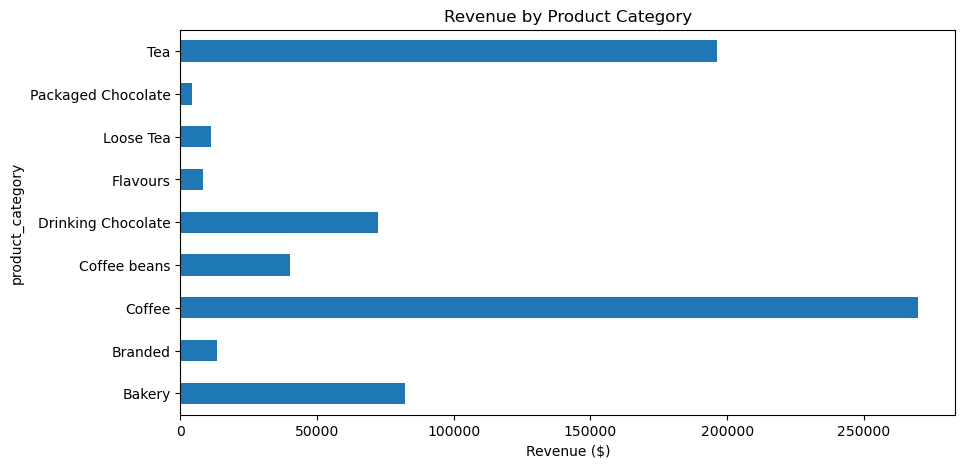

In [2]:
# Your basic chart here
cat_revenue = df.groupby('product_category')['revenue'].sum()

plt.figure(figsize=(10, 5))
cat_revenue.plot(kind='barh')
plt.title('Revenue by Product Category')
plt.xlabel('Revenue ($)')
plt.show()

### Things to look out for
- Is there one clear leader, or are the categories close?
- The bars aren't sorted — sorting them makes the ranking immediately obvious
- All bars are the same colour — nothing draws the eye to the top performer
- Can you tell the exact revenue for each bar without guessing from the axis?

### Optional extras to try
- Sort the bars: add `.sort_values(ascending=True)` before plotting
- Highlight the top bar in amber and the rest in teal:
  ```python
  colors = ['#E69F00' if i == len(cat_revenue)-1 else '#009E73'
            for i in range(len(cat_revenue))]
  plt.barh(cat_revenue.index, cat_revenue.values, color=colors)
  ```
- Add value labels: `plt.text(v * 1.01, i, f'${v:,.0f}', va='center', fontsize=9)`
- Change the title to state the finding rather than just describing the chart
- Add `sns.despine()` for a cleaner look

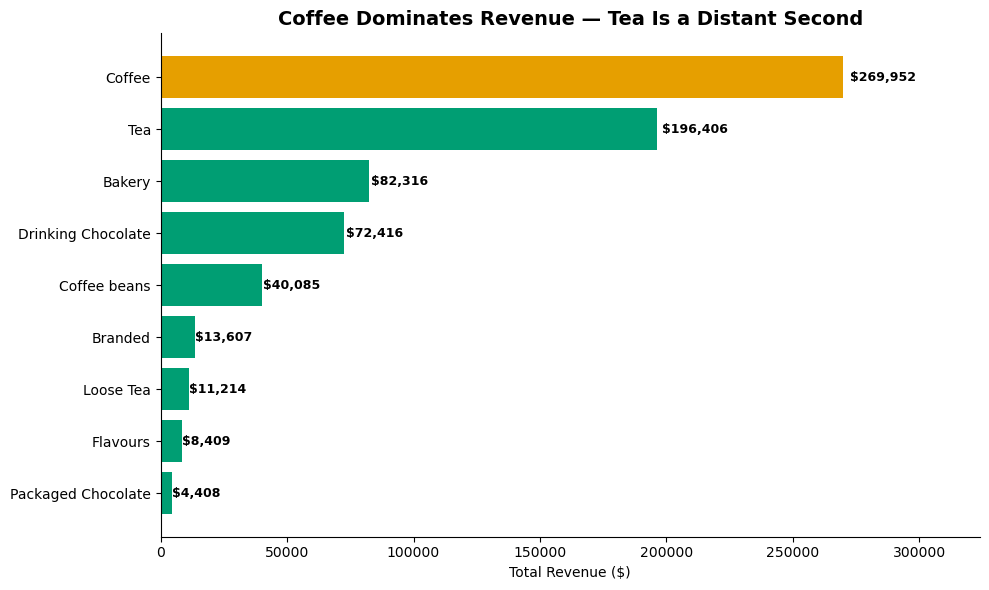

In [3]:
# Your improved chart here
cat_revenue = df.groupby('product_category')['revenue'].sum().sort_values(ascending=True)

colors = ['#E69F00' if i == len(cat_revenue)-1 else '#009E73'
          for i in range(len(cat_revenue))]

plt.figure(figsize=(10, 6))
plt.barh(cat_revenue.index, cat_revenue.values, color=colors)

for i, v in enumerate(cat_revenue.values):
    plt.text(v * 1.01, i, f'${v:,.0f}', va='center', fontsize=9, weight='bold')

plt.title('Coffee Dominates Revenue — Tea Is a Distant Second',
          fontsize=14, weight='bold')
plt.xlabel('Total Revenue ($)')
plt.xlim(0, cat_revenue.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()


---
## Task 2 — How has revenue grown month by month?

The business wants to see whether revenue is growing across the six months and spot any peaks or dips. Which chart would suit best to show direction and continuity for time-based data?

**Columns you'll need:** `month_name`, `revenue`

**Key step:** `df.groupby('month_name')['revenue'].sum()`

> Months will sort alphabetically by default. Fix this with:  
> `month_order = ['Jan','Feb','Mar','Apr','May','Jun']`  
> then monthly = df.groupby('month_name')['revenue'].sum().reindex(month_order)

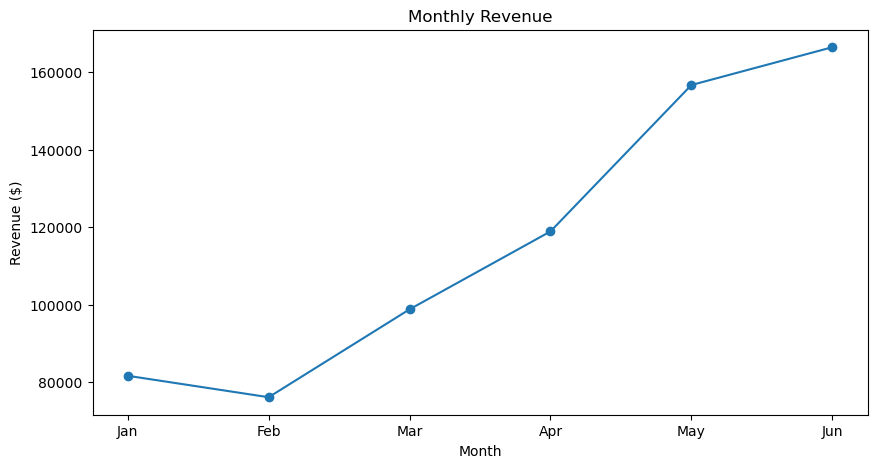

In [4]:
# Your basic chart here
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly = df.groupby('month_name')['revenue'].sum().reindex(month_order)

plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.show()

### Things to look out for
- Is the trend consistently upward, or are there any dips?
- The y-axis shows raw numbers — `$140000` is harder to read than `$140K`
- The peak month isn't annotated — a reader has to estimate it from the axis
- The default line style and colour are quite plain

### Optional extras to try
- Style the line: `color='#009E73', linewidth=2.5`
- Mark the peak with a dot:  
  ```python
  peak_idx = monthly.values.argmax()
  plt.scatter(monthly.index[peak_idx], monthly.values[peak_idx],
              color='#D55E00', s=100, zorder=5)
  ```
- Add a text label next to the peak dot using `plt.text()`
- Format the y-axis as `$K`:  
  `plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))`
- Use `sns.set_style('whitegrid')` for a cleaner background grid

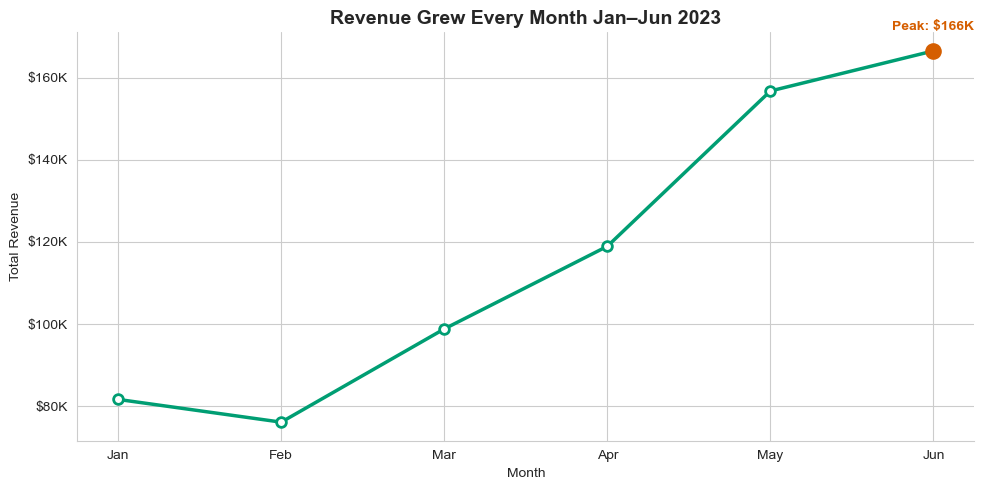

In [5]:
# Your improved chart here
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly = df.groupby('month_name')['revenue'].sum().reindex(month_order)

peak_idx   = monthly.values.argmax()
peak_month = monthly.index[peak_idx]
peak_val   = monthly.values[peak_idx]

plt.figure(figsize=(10, 5))
sns.set_style('whitegrid')

plt.plot(monthly.index, monthly.values,
         color='#009E73', linewidth=2.5, marker='o',
         markersize=7, markerfacecolor='white', markeredgewidth=2)

# Highlight the peak
plt.scatter(peak_month, peak_val, color='#D55E00', s=120, zorder=5)
plt.text(peak_idx, peak_val * 1.03,
         f'Peak: ${peak_val/1000:.0f}K',
         ha='center', color='#D55E00', fontsize=10, weight='bold')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.title('Revenue Grew Every Month Jan–Jun 2023', fontsize=14, weight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
sns.despine()
plt.tight_layout()
plt.show()

---
## Task 3 — Which hours of the day are the busiest?

The business wants to know when to have the most staff on shift. Which hours have the most transactions? 

**Columns you'll need:** `hour`, `transaction_id` (count)

**Key step:** `df.groupby('hour')['transaction_id'].count()`

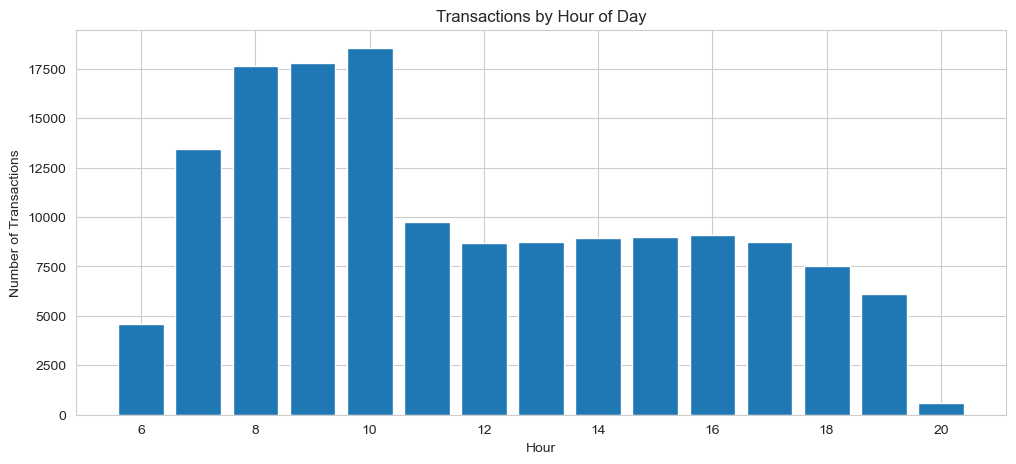

In [6]:
# Your basic chart here
hourly = df.groupby('hour')['transaction_id'].count().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(hourly.index, hourly.values)
plt.title('Transactions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.show()

### Things to look out for
- Hours are shown as numbers (6, 7, 8...) — labels like `6am` or `2pm` are clearer
- Is there a clear morning rush? When does footfall drop off?
- Every bar is the same colour — there's no visual signal for which hours are busier than average

### Optional extras to try
- Convert hour numbers to readable labels:  
  ```python
  def fmt_hour(h):
      if h == 12: return '12pm'
      return f'{h}am' if h < 12 else f'{h-12}pm'
  hour_labels = [fmt_hour(h) for h in hourly.index]
  ```
  Then use `plt.bar(range(len(hourly)), hourly.values, tick_label=hour_labels)`
- Calculate the average and colour bars: amber if above average, teal if below:
  ```python
  avg = hourly.mean()
  colors = ['#E69F00' if v >= avg else '#009E73' for v in hourly.values]
  ```
- Add a dashed average reference line: `plt.axhline(avg, color='grey', linestyle='--')`
- Shade the morning rush window: `plt.axvspan(0.5, 4.5, alpha=0.08, color='orange')`  
  *(x positions here are bar indices starting from 0, not the hour numbers)*

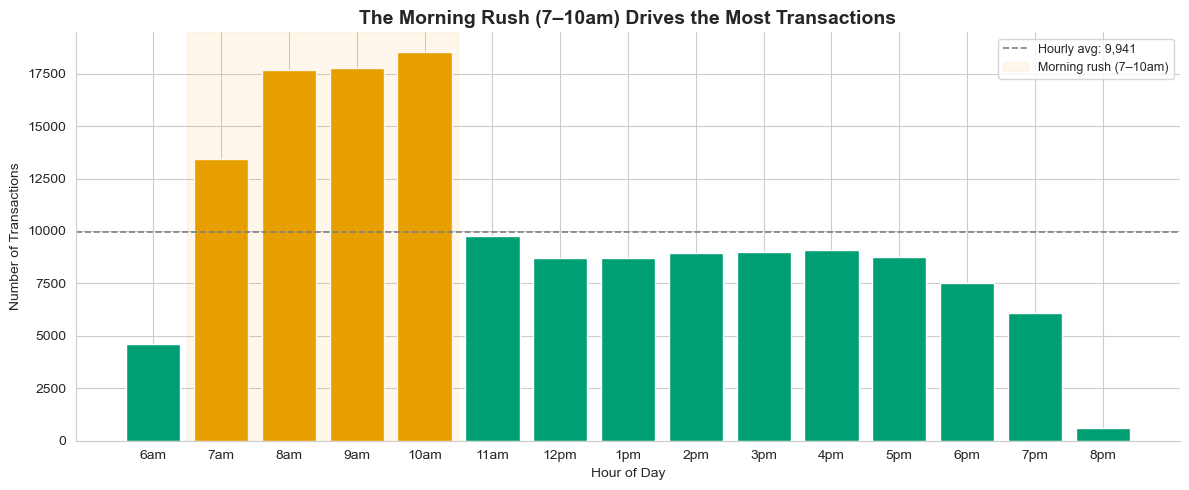

In [7]:
# Your improved chart here
hourly = df.groupby('hour')['transaction_id'].count().sort_index()
avg    = hourly.mean()

def fmt_hour(h):
    if h == 12: return '12pm'
    return f'{h}am' if h < 12 else f'{h-12}pm'

hour_labels = [fmt_hour(h) for h in hourly.index]
colors = ['#E69F00' if v >= avg else '#009E73' for v in hourly.values]

plt.figure(figsize=(12, 5))
plt.bar(range(len(hourly)), hourly.values, color=colors, tick_label=hour_labels)
plt.axhline(avg, color='grey', linestyle='--', linewidth=1.2,
            label=f'Hourly avg: {avg:,.0f}')

# Shade the morning rush (bar indices 1–4 = hours 7–10am)
plt.axvspan(0.5, 4.5, alpha=0.08, color='orange', label='Morning rush (7–10am)')

plt.title('The Morning Rush (7–10am) Drives the Most Transactions',
          fontsize=14, weight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

---
## Task 4 — How do the three store locations compare over time?

Are all three stores growing at the same rate, or is one pulling ahead? Plotting a separate line per store on the same chart lets you compare their trends side by side.

**Columns you'll need:** `store_location`, `month_name`, `revenue`

**Key steps:**
```python
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Filter to one store, group by month, reindex to keep the right order
store1 = df[df['store_location'] == 'Astoria']
store1_monthly = store1.groupby('month_name')['revenue'].sum().reindex(month_order)

# Then plot each store as a separate line
plt.plot(store1_monthly.index, store1_monthly.values, label='Astoria')
```

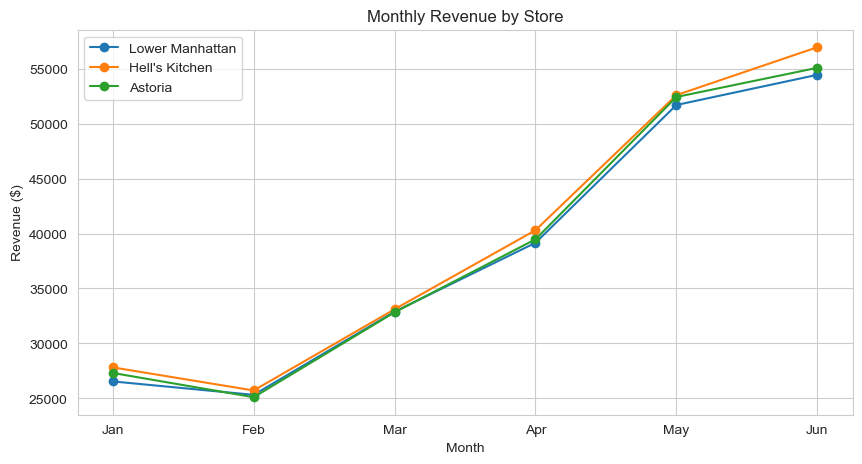

In [8]:
# Your basic chart here
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
stores = df['store_location'].unique()

plt.figure(figsize=(10, 5))

for store in stores:
    monthly = (df[df['store_location'] == store]
               .groupby('month_name')['revenue']
               .sum()
               .reindex(month_order))
    plt.plot(monthly.index, monthly.values, marker='o', label=store)

plt.title('Monthly Revenue by Store')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.legend()
plt.show()

### Things to look out for
- Are the three lines close together or spread apart?
- Do all stores follow the same trend, or does one behave differently?
- The default colours are fine but not colour-blind friendly — try assigning deliberate colours
- The y-axis raw numbers could be formatted as `$K`

### Optional extras to try
- Assign a specific colour to each store:
  ```python
  store_colors = {
      'Astoria':         '#0072B2',
      "Hell's Kitchen":  '#E69F00',
      'Lower Manhattan': '#009E73'
  }
  # then use: color=store_colors[store] inside the loop
  ```
- Add `linewidth=2` and `markersize=7` for a cleaner line
- Format the y-axis as `$K`
- Try **direct labelling** — add the store name at the end of each line instead of using a legend:  
  `plt.text(5.1, monthly.values[-1], store.split()[0], color=..., fontsize=9, va='center')`  
  *(5.1 is just past the last x position — Jun is index 5)*

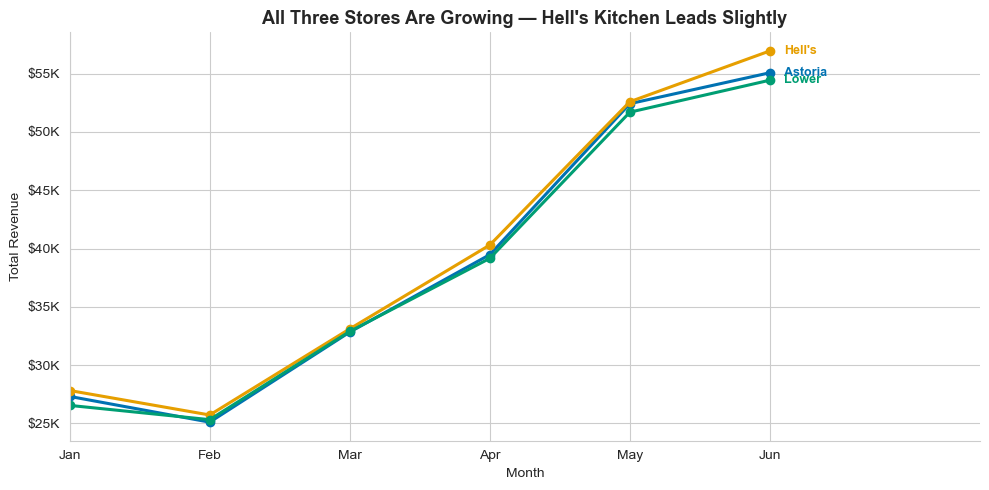

In [11]:
# Your improved chart here
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
store_colors = {
    'Astoria':         '#0072B2',
    "Hell's Kitchen":  '#E69F00',
    'Lower Manhattan': '#009E73'
}

plt.figure(figsize=(10, 5))
sns.set_style('whitegrid')

for store, color in store_colors.items():
    monthly = (df[df['store_location'] == store]
               .groupby('month_name')['revenue']
               .sum()
               .reindex(month_order))
    plt.plot(monthly.index, monthly.values,
             color=color, linewidth=2.2, marker='o', markersize=6)
    # Direct label at the end of each line
    plt.text(5.1, monthly.values[-1],
             store.split()[0], color=color, fontsize=9, va='center', weight='bold')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.title("All Three Stores Are Growing — Hell's Kitchen Leads Slightly",
          fontsize=13, weight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xlim(0, 6.5)  # Leave space for the direct labels
sns.despine()
plt.tight_layout()
plt.show()

---
## Task 5 — What does a typical transaction look like?

The finance team wants to understand how individual transaction values are spread. Are most customers spending under $5? Over $10? Is there a wide range or does spending cluster tightly? Hint - we are looking for a shape of a distribution here.

**Columns you'll need:** `revenue` (one row = one transaction — no groupby needed!)

**Key step:** `plt.hist(df['revenue'], bins=40)`

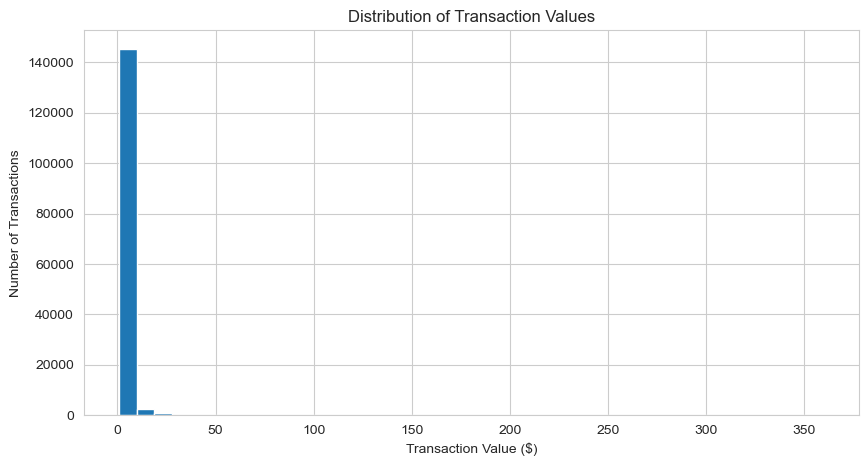

In [12]:
# Your basic chart here
plt.figure(figsize=(10, 5))
plt.hist(df['revenue'], bins=40)
plt.title('Distribution of Transaction Values')
plt.xlabel('Transaction Value ($)')
plt.ylabel('Number of Transactions')
plt.show()

### Things to look out for
- Does everything get squashed into the left side? That means a few very large transactions are stretching the x-axis — this is called a **right-skewed distribution** and is very common with spending data
- Try capping the x-axis to zoom into where most transactions sit: `plt.xlim(0, 20)`
- Where does the bulk of spending fall — under $5, $5–10, $10+?

### Optional extras to try
- Cap the x-axis to focus on typical transactions: `plt.xlim(0, 20)`
- Change bar colour to teal and add white edges: `color='#009E73', edgecolor='white'`
- Add a vertical line showing the **median** (the middle value):  
  `plt.axvline(df['revenue'].median(), color='#D55E00', linestyle='--', label='Median')`
- Add a vertical line showing the **mean** (the average) in a different colour — if the mean is higher than the median, the distribution is skewed
- Add `plt.legend()` so the lines are labelled

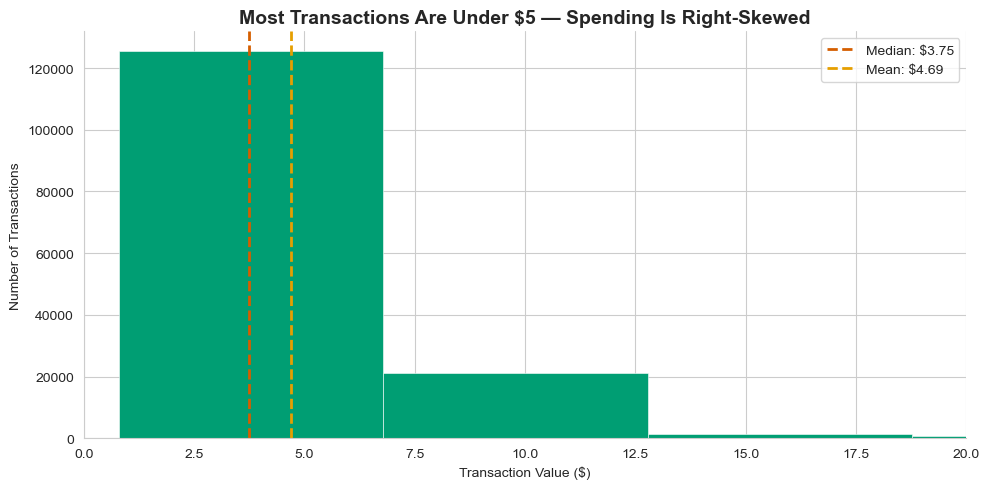

In [13]:
# Your improved chart here
median_val = df['revenue'].median()
mean_val   = df['revenue'].mean()

plt.figure(figsize=(10, 5))
plt.hist(df['revenue'], bins=60, color='#009E73', edgecolor='white', linewidth=0.4)

plt.axvline(median_val, color='#D55E00', linestyle='--', linewidth=2,
            label=f'Median: ${median_val:.2f}')
plt.axvline(mean_val, color='#E69F00', linestyle='--', linewidth=2,
            label=f'Mean: ${mean_val:.2f}')

plt.xlim(0, 20)  # Focus on where most transactions sit
plt.title('Most Transactions Are Under $5 — Spending Is Right-Skewed',
          fontsize=14, weight='bold')
plt.xlabel('Transaction Value ($)')
plt.ylabel('Number of Transactions')
plt.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

---
## Task 6 — Which store and category combinations generate the most revenue?

The operations team wants to see revenue broken down by both **store location** and **product category** at the same time. Which chart type would suit best here if we want to spot which combinations are strong or weak (hint - looking for a grid).

**Columns you'll need:** `store_location`, `product_category`, `revenue`


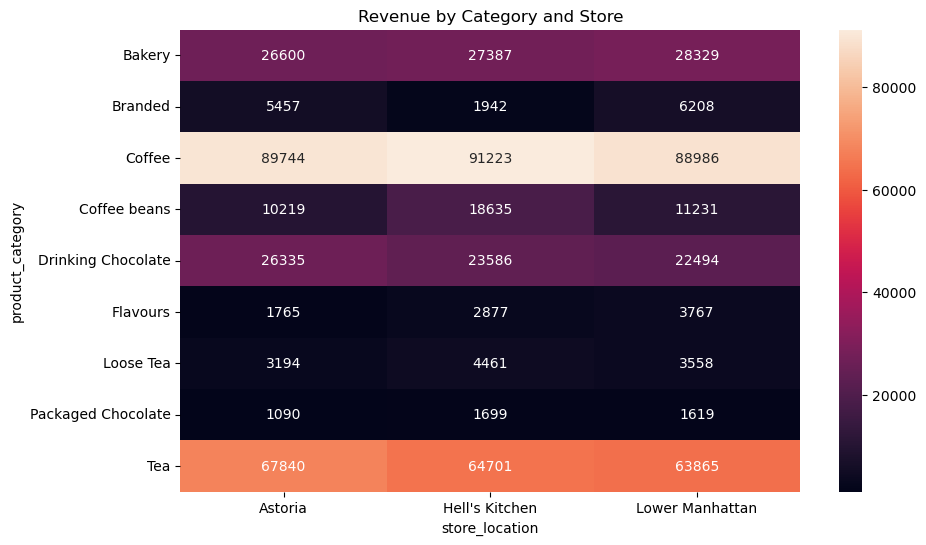

In [5]:
# Your basic chart here
pivot = df.pivot_table(values='revenue', index='product_category',
                       columns='store_location', aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f')
plt.title('Revenue by Category and Store')
plt.show()

### Things to look out for
- The raw numbers in the basic chart are hard to read — `$45678.90` in a small cell is cluttered
- The default colour palette (`viridis`) works, but doesn't naturally suggest "high is good"
- Are some category × store combinations noticeably stronger or weaker than the rest?
- Do all three stores show a similar pattern, or does one store have a different product mix?

### Optional extras to try
- Format annotations as `$K` for cleaner cells:  
  `annot_labels = pivot.map(lambda v: f'${v/1000:.0f}K')`  
  then pass `annot=annot_labels, fmt=''` to `sns.heatmap()`
- Use `cmap='YlOrRd'` (yellow → orange → red) for a more intuitive "low to high" colour scale
- Add `linewidths=0.5, linecolor='white'` to separate cells clearly
- Set `annot_kws={'size': 10, 'weight': 'bold'}` for bolder labels
- Write a title that states what the pattern is, not just what the chart shows

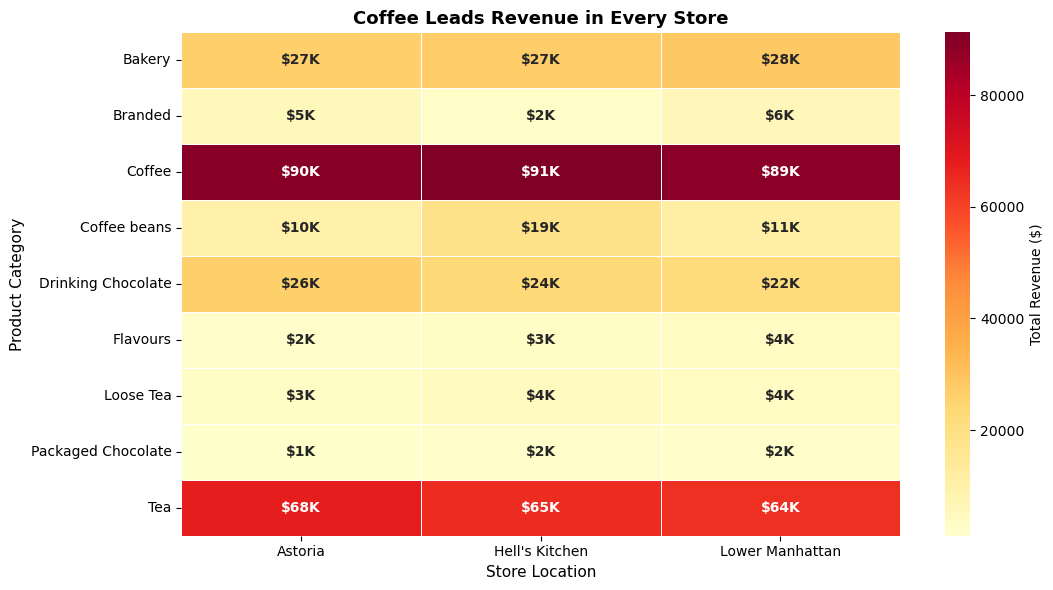

In [7]:
# Your improved chart here
pivot = df.pivot_table(values='revenue', index='product_category',
                       columns='store_location', aggfunc='sum')

# Format annotations as $K
annot_labels = pivot.map(lambda v: f'${v/1000:.0f}K')

plt.figure(figsize=(11, 6))
sns.heatmap(
    pivot,
    annot=annot_labels,
    fmt='',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 10, 'weight': 'bold'},
    cbar_kws={'label': 'Total Revenue ($)'}
)

plt.title('Coffee Leads Revenue in Every Store',
          fontsize=13, weight='bold')
plt.xlabel('Store Location', fontsize=11)
plt.ylabel('Product Category', fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Task 7 — Your own question
**Chart type: Your choice**

The final task is entirely yours. Explore the dataset, find something interesting, and visualise it — choosing the chart type that best fits your question.

Some ideas if you need a starting point:

| Idea | Suggested chart | Columns |
|------|-----------------|----------|
| Which specific products generate the most revenue? | Horizontal bar (top 10) | `product_detail`, `revenue` |
| Which product type is most popular? | Horizontal bar | `product_type`, `transaction_id` |
| Does one store have a noticeably different busiest hour? | Multi-line or bar | `store_location`, `hour` |
| How does transaction count trend month by month? | Line chart | `month_name`, `transaction_id` |

In [ ]:
# Your basic chart here


### Before improving your chart, ask yourself:
- Does your title state the **finding**, not just describe the chart?
- Is the **chart type** the right fit for your question?
- Is colour doing a **job** — or is it just decoration?
- Would a reader understand the chart **without reading the code**?

### Don't forget the finishing touches
- `sns.despine()` — removes the top and right borders
- `plt.tight_layout()` — fixes overlapping labels
- `plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')` — cleaner y-axis numbers

In [ ]:
# Your improved chart here


---
##  Reflection

Before you finish, take a moment to answer these:

1. **Which chart type is the hardest for you to understand/apply?** 
2. **Which task was hardest?** Was it the code, the data, or deciding what to show?
3. **Did anything surprise you** in the data?
4. **What one recommendation** would you make to Maven Roasters based on your findings?

---

##  Quick Reference

**When to use which chart:**

| Question | Chart |
|----------|-------|
| Rank categories | Horizontal bar chart |
| Show a trend over time | Line chart |
| Compare groups over time | Multi-line chart |
| Show distribution of a variable | Histogram |

**Colours:**

| Use | Hex |
|-----|-----|
| Highlight / top value | `#E69F00` |
| Base / positive | `#009E73` |
| Annotation / peak | `#D55E00` |
| Weekdays | `#2a9d8f` |
| Weekends | `#e9c46a` |

**Useful one-liners:**
```python
sns.despine()                             # Remove top and right border
plt.tight_layout()                        # Fix overlapping labels
plt.xticks(rotation=45, ha='right')       # Rotate x-axis labels
plt.gca().yaxis.set_major_formatter(      # Format y-axis as $K
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.axhline(val, linestyle='--', color='grey')    # Horizontal reference line
plt.axvline(val, linestyle='--', color='#D55E00') # Vertical reference line
plt.text(x, y, 'label', ha='center', fontsize=9) # Text annotation
```